# Habit Tracker Data Analysis Dashboard

## Objective
Analyze user habit data to identify:
- Consistency patterns
- Habit difficulty
- Behavioral trends

Tools Used:
- SQLite
- Python (pandas, matplotlib, seaborn)

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [3]:
def load_data(db_path):
    with sqlite3.connect(db_path) as conn:
        users = pd.read_sql_query("SELECT * FROM users", conn)
        habits = pd.read_sql_query("SELECT * FROM habits", conn)
        habit_logs = pd.read_sql_query("SELECT * FROM habit_logs", conn)
    return users, habits, habit_logs

users, habits, habit_logs = load_data("Project1.db")

## Data Overview

In [4]:
users.head()
habits.head()
habit_logs.head()

,log_id,user_id,habit_id,date,status,time_spent,notes
0,1,1,1,2024-10-01,1,43,"Early morning, very focused"
1,2,1,2,2024-10-01,1,13,NULL
2,3,1,3,2024-10-01,1,0,NULL
3,4,1,4,2024-10-01,1,32,Best session this week
4,5,1,5,2024-10-01,1,26,NULL


## Data Preparation
We combine all tables to analyze behavior across users and habits.

In [12]:
df = (
    habit_logs
    .merge(users, on="user_id", how="left")
    .merge(habits, on="habit_id", how="left")
)

df.head()

,log_id,user_id,habit_id,date,status,time_spent,notes,name,habit_name,category
0,1,1,1,2024-10-01,1,43,"Early morning, very focused",Abhishek,Morning Exercise,Health
1,2,1,2,2024-10-01,1,13,NULL,Abhishek,Read 30 minutes,Learning
2,3,1,3,2024-10-01,1,0,NULL,Abhishek,Drink 3L Water,Health
3,4,1,4,2024-10-01,1,32,Best session this week,Abhishek,No Social Media after 9 PM,Discipline
4,5,1,5,2024-10-01,1,26,NULL,Abhishek,Learn SQL / Coding,Learning


We convert status into binary for analysis (1 = completed, 0 = not completed).

In [13]:
df["completed"] = (df["status"] == 1).astype(int)

In [14]:
user_rate = (
    df.groupby("name")["completed"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"name": "User", "completed": "Completion Rate (%)"})
    .sort_values("Completion Rate (%)", ascending=False)
)

habit_rate = (
    df.groupby("habit_name")["completed"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"habit_name": "Habit", "completed": "Completion Rate (%)"})
    .sort_values("Completion Rate (%)", ascending=False)
)

daily_trend = (
    df[df["completed"] == 1]
    .groupby("date")
    .size()
    .reset_index(name="Completed Count")
)

category_rate = (
    df.groupby("category")["completed"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index()
    .rename(columns={"category": "Category", "completed": "Completion Rate (%)"})
)

heatmap_data = (
    df.groupby(["name", "habit_name"])["completed"]
    .mean()
    .mul(100)
    .round(1)
    .unstack(fill_value=0)
)

## Visual Analysis

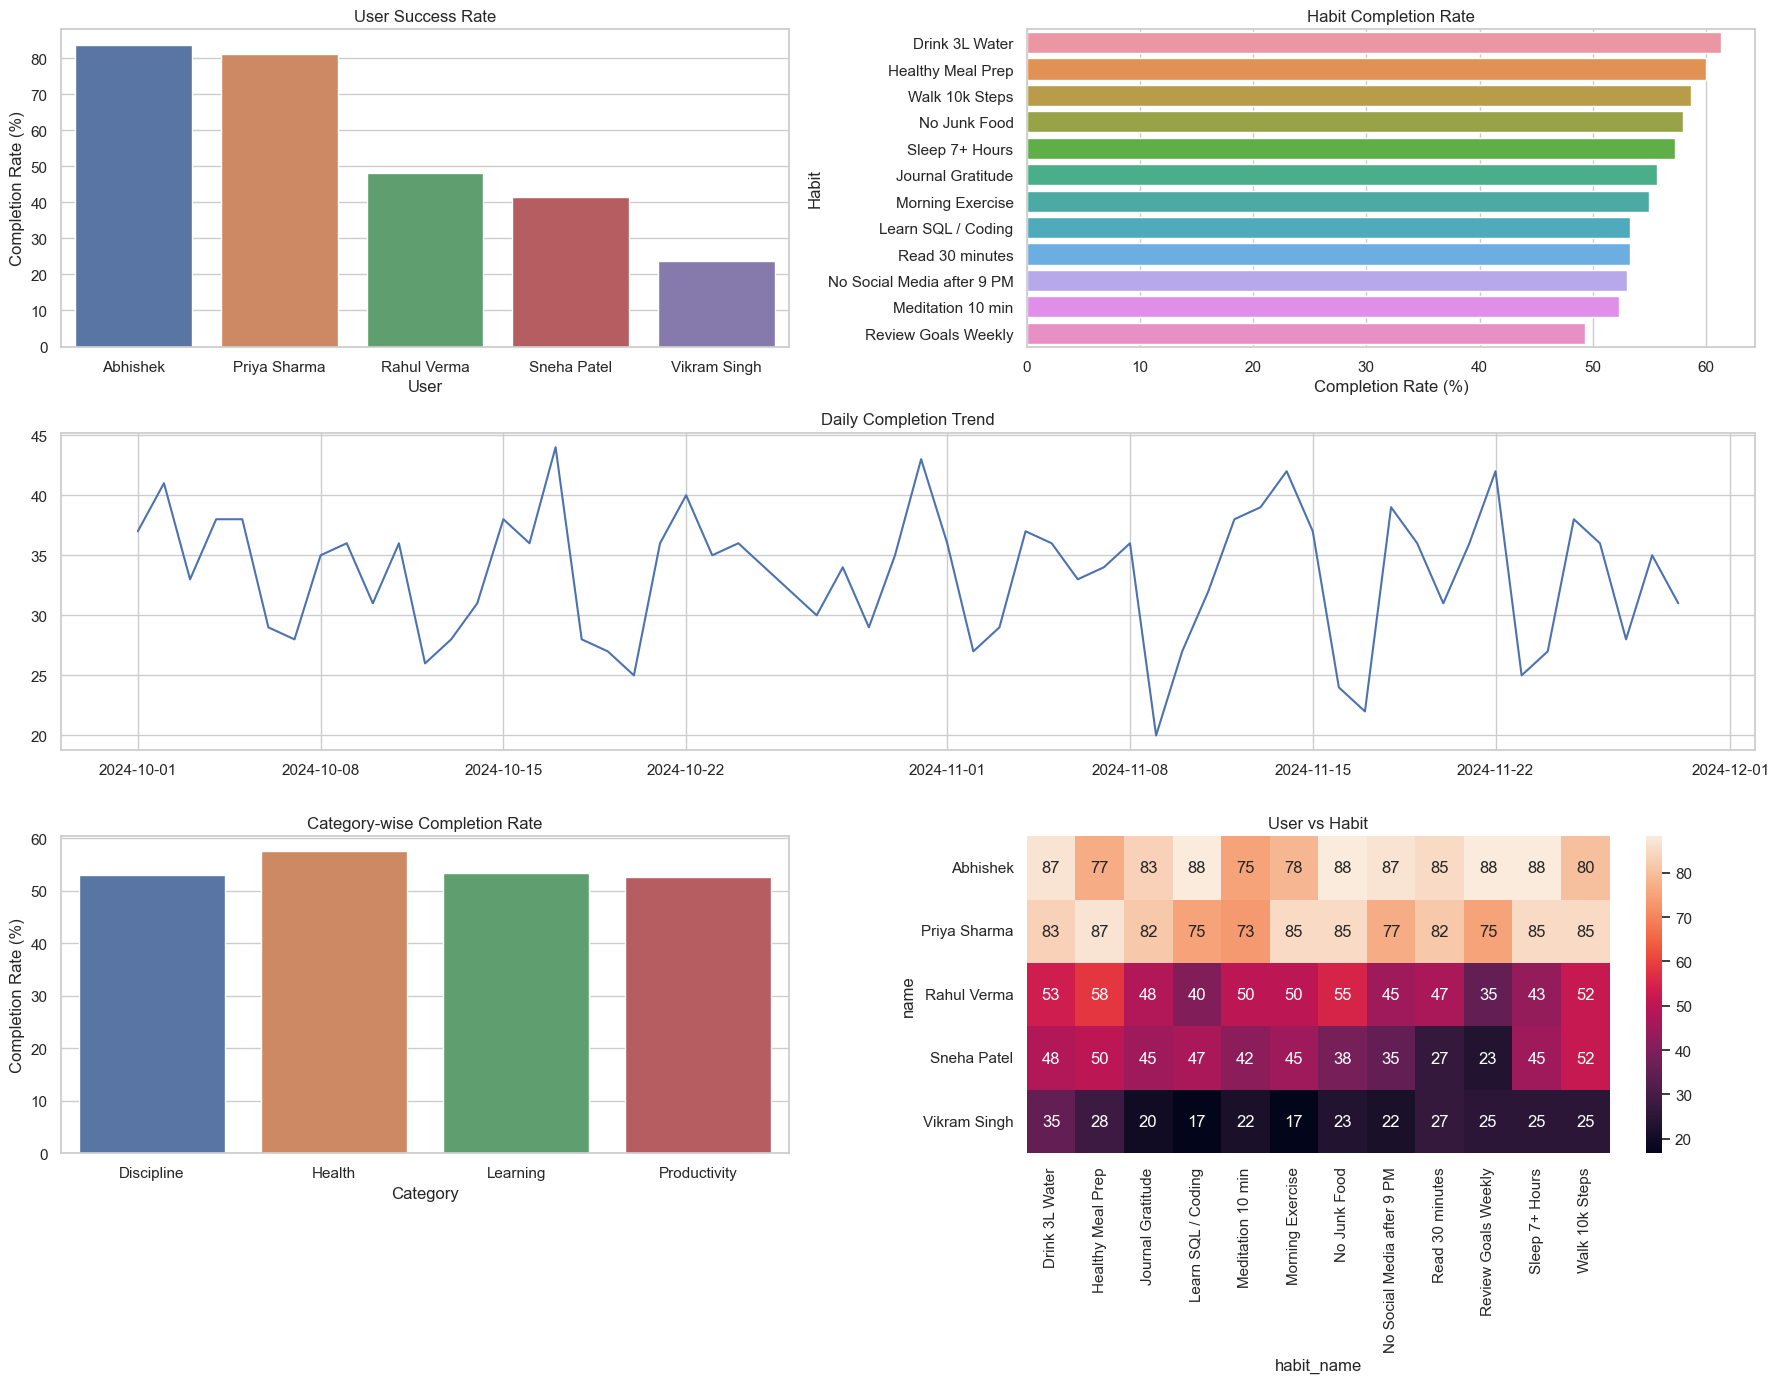

In [15]:
sns.set_theme(style="whitegrid")

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

sns.barplot(data=user_rate, x="User", y="Completion Rate (%)", ax=ax1)
ax1.set_title("User Success Rate")

sns.barplot(data=habit_rate, x="Completion Rate (%)", y="Habit", ax=ax2)
ax2.set_title("Habit Completion Rate")

ax3.plot(daily_trend["date"], daily_trend["Completed Count"])
ax3.set_title("Daily Completion Trend")

sns.barplot(data=category_rate, x="Category", y="Completion Rate (%)", ax=ax4)
ax4.set_title("Category-wise Completion Rate")

sns.heatmap(heatmap_data, annot=True, fmt=".0f", ax=ax5)
ax5.set_title("User vs Habit")

plt.tight_layout()
plt.show()

## Key Insights

- Overall completion rate ≈ 56%
- Most consistent user: Abhishek (~83%)
- Hardest habit: Review Goals Weekly (~49%)
- Most consistent habit: Drink 3L Water (~61%)
- Health category performs best
- Daily trend is fluctuating